In [ ]:
!pip install qiskit qiskit-aer qiskit[visualization]


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from itertools import islice

In [ ]:
# Initialize quantum circuit with one qubit and one classical bit
circ = QuantumCircuit(1, 1)

# Apply Hadamard gate to qubit at the index 0
circ.h(0)

# Measure the qubit at index 0 and store in the classical bit at index 0
circ.measure(0,0)

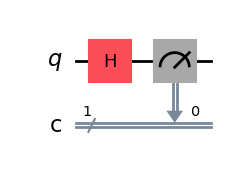

In [ ]:
# Draw the quantum circuit using matplotlib
circ.draw("mpl")

In [ ]:
print("Details of Classical Register: ", circ.cregs)
# Details of Classical Register:  [ClassicalRegister(1, 'c')]

print("Details of Quantum Register: ", circ.qregs)
# Details of Quantum Register:  [QuantumRegister(1, 'q')]

Details of Classical Register:  [ClassicalRegister(1, 'c')]
Details of Quantum Register:  [QuantumRegister(1, 'q')]


In [ ]:
# Initializing the simulator
backend = AerSimulator()

# Transpile 
circ = transpile(circ, backend)

In [ ]:
# Run the simulator 640000 times to generate 1000 64-bit number
result = backend.run(circ, shots=64*10000, memory=True).result()

# Extract the results from memory in a list and print them
memory = result.get_memory(circ)
# print(memory)

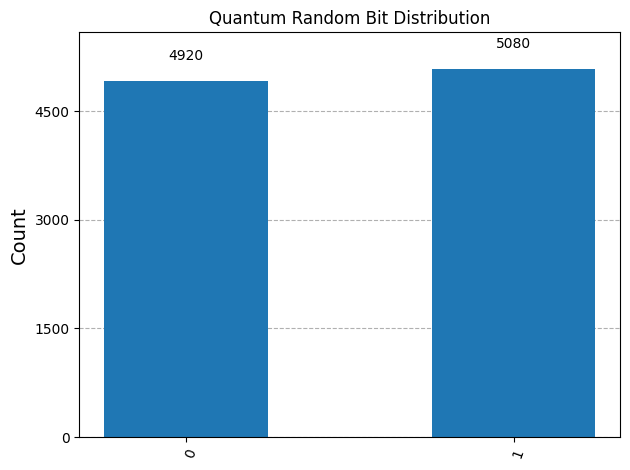

In [ ]:
# Get the data of our experiment
counts = result.get_counts(circ)

# Plot the data in a histogram
plot_histogram(counts, title='Quantum Random Bit Distribution')

In [ ]:
a = memory  
n = 64  

it = iter(a) 
res = [str(int(''.join((islice(it, n))) , 2)) for _ in range((len(a) + n - 1) // n)]
print(len(res))

10000


In [ ]:
with open("simulated.txt", "w") as f:
    f.write("\n".join(res))